## **Dependencies**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from nltk import FreqDist
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize
import nltk
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from nltk.sentiment import SentimentIntensityAnalyzer
from transformers import pipeline
import string
from gensim.models import KeyedVectors
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from google.colab import drive
from sklearn.metrics import f1_score, confusion_matrix
drive.mount('/content/drive')

warnings.filterwarnings("ignore")

Mounted at /content/drive


## **Load data**

In [3]:
df = pd.read_csv('airfrance_tripadvisor_reviews.csv')

About the data:

*   text: Contains the main text of each customer review, providing feedback on their experience with Air France.
*   rating: Numerical rating assigned by the customer, usually on a scale of 1 to 5, with 5 being the highest.
*   publishedDate: The date when the review was posted, formatted as YYYY-MM-DD.
*   title: title of the review




## **Raw dataset overview**

In [ ]:
print('Dataset number of records: %s' % df.shape[0])
print('Dataset number of columns: %s' % df.shape[1])
df.head()

In [ ]:
df.describe(include=['object']).T

,count,unique,top,freq
title,2560,2391,Air France,16
text,2560,2560,I travel a lot - and I travel often. Last week...,1
publishedDate,2560,602,2016-08-03,80


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   rating         2560 non-null   int64 
 1   title          2560 non-null   object
 2   text           2560 non-null   object
 3   publishedDate  2560 non-null   object
dtypes: int64(1), object(3)
memory usage: 80.1+ KB


In [ ]:
df.duplicated().any()

False

In [ ]:
df.nunique()

,0
rating,5
title,2391
text,2560
publishedDate,602


Observations:

*   We do not have any duplicate values
*   We do not have any missing value
*   The date is as an object type


## **Exploratory Data Analysis (EDA)**

**Rating Distribution**

Let's take a look at the rating distribution in our data

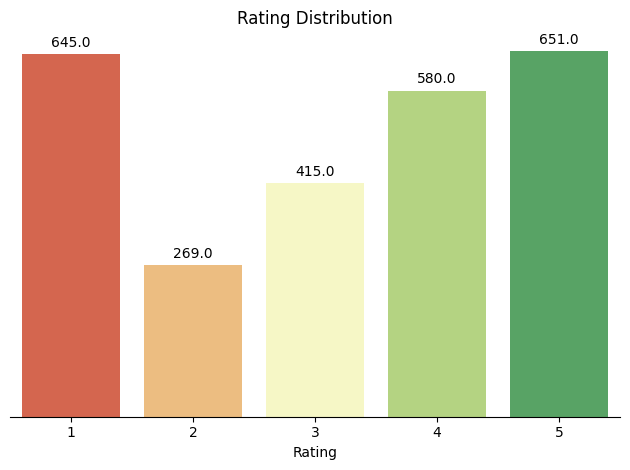

In [ ]:
ax = sns.countplot(x='rating', data=df, palette="RdYlGn")
for p in ax.patches:
  ax.annotate(f'{p.get_height()}',
              (p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='center',
              xytext=(0, 8),
              textcoords='offset points')
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('')
ax.yaxis.set_visible(False)
plt.title(f'Rating Distribution')
plt.xlabel('Rating')
plt.tight_layout()
plt.show()

we can see that we have 914 bad reviews, 415 neutral reviews and 1231 good reviews.

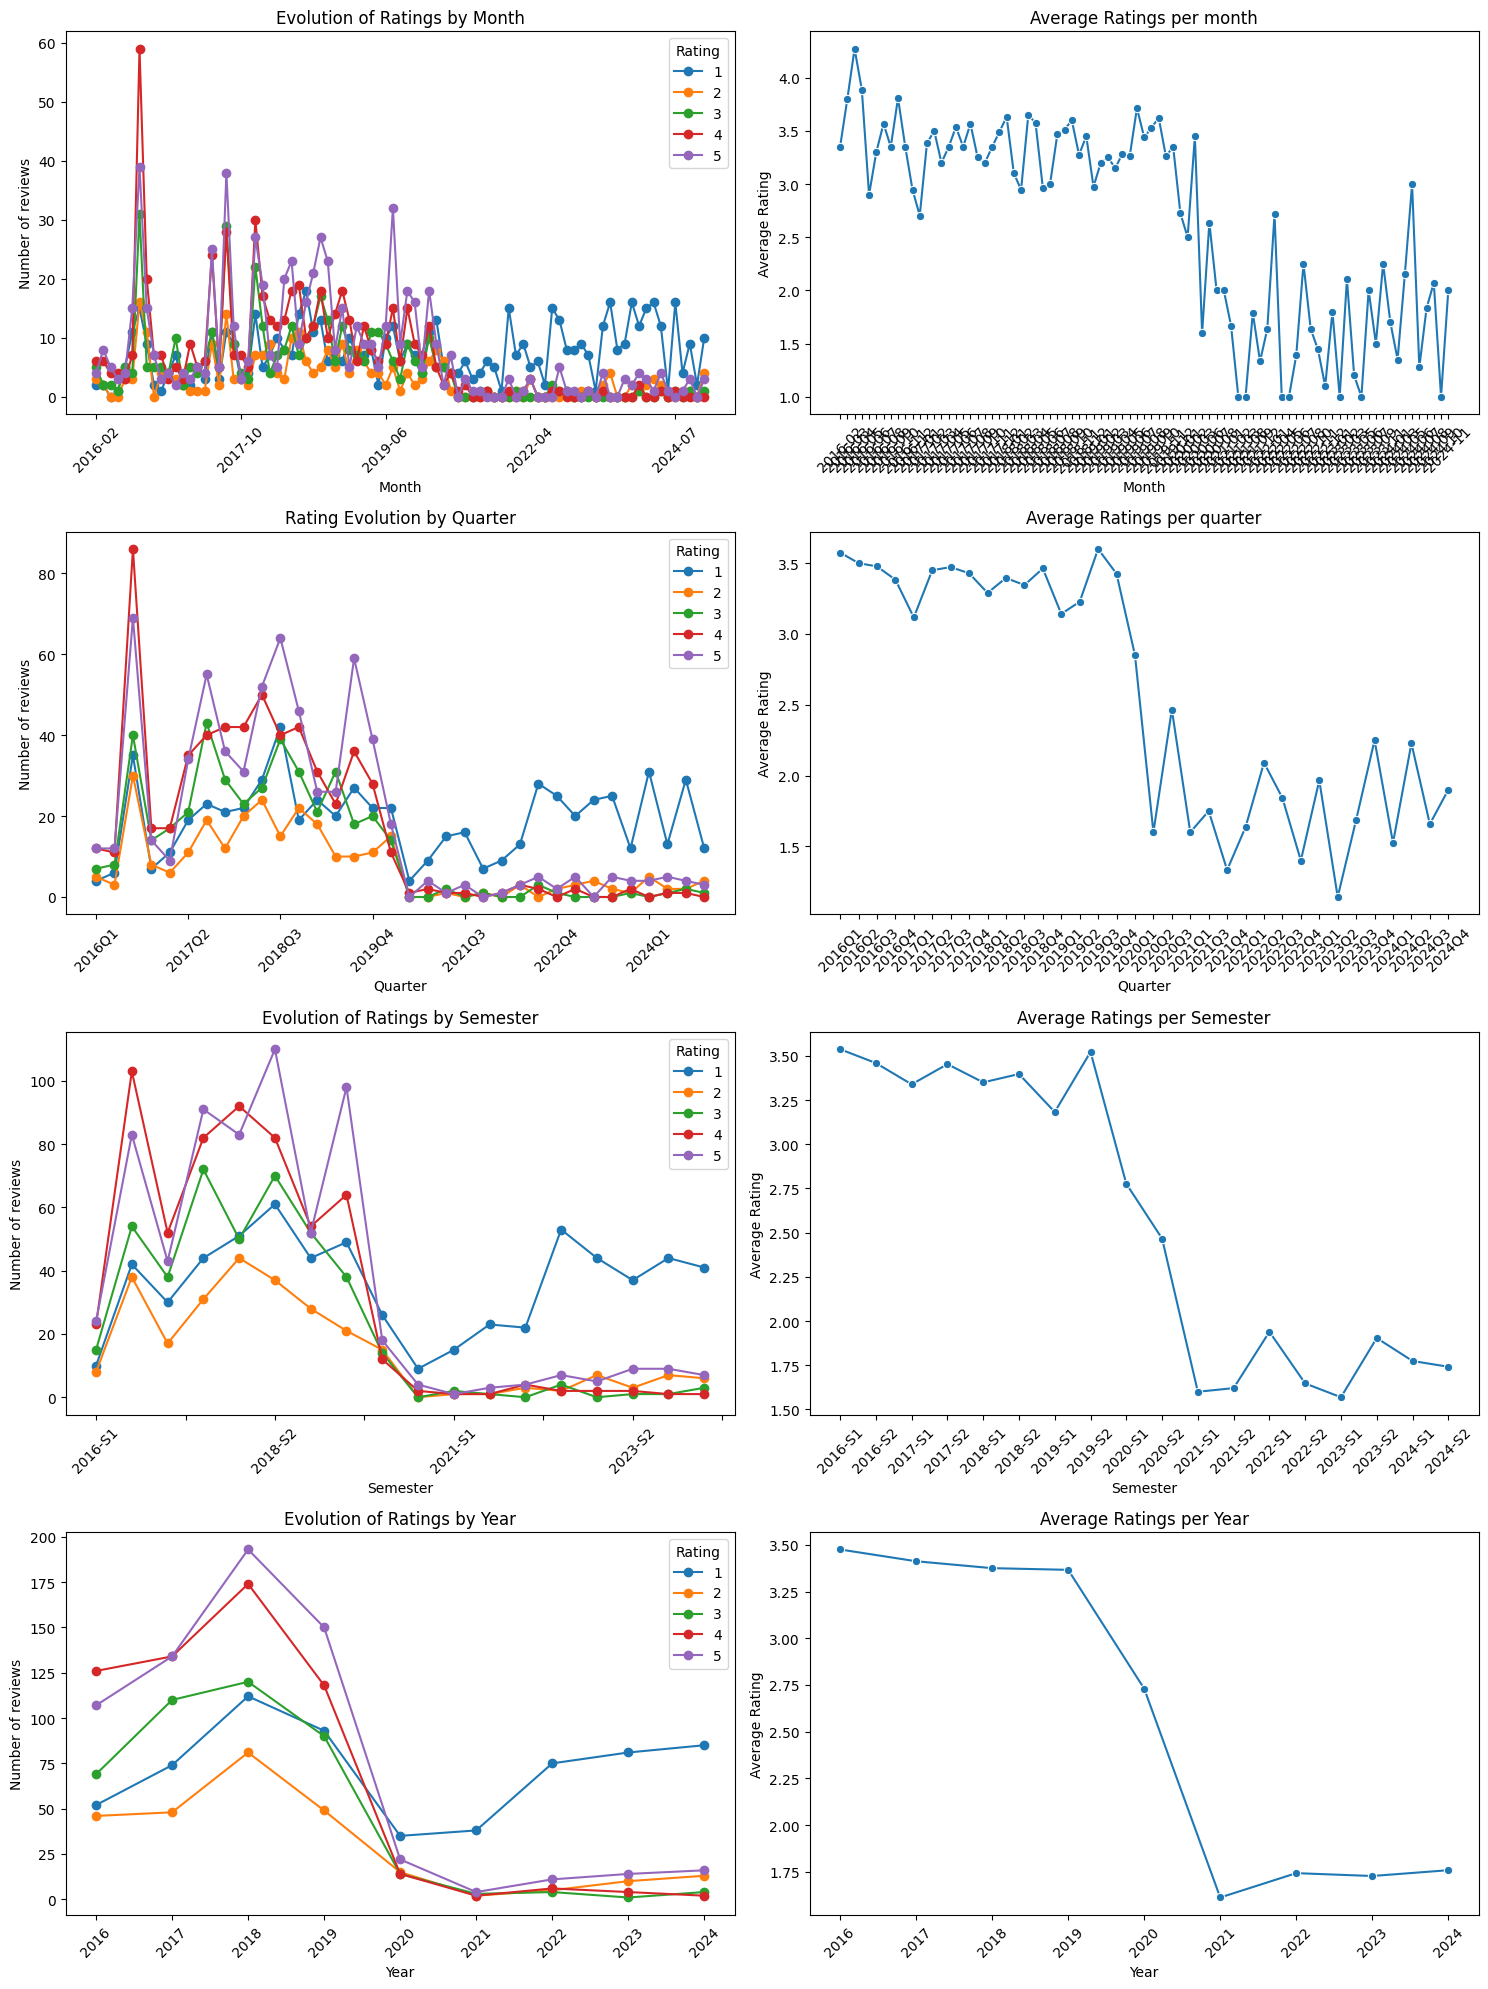

In [ ]:
df_copy = df.copy()
df_copy['publishedDate'] = pd.to_datetime(df_copy['publishedDate'])

df_copy['year_month'] = df_copy['publishedDate'].dt.to_period('M').astype(str)
df_copy['year_quarter'] = df_copy['publishedDate'].dt.to_period('Q').astype(str)
df_copy['year_semester'] = df_copy['publishedDate'].apply(lambda x: f"{x.year}-S1" if x.month <= 6 else f"{x.year}-S2")
df_copy['year'] = df_copy['publishedDate'].dt.year.astype(str)

ratings_by_month = df_copy.groupby(['year_month', 'rating']).size().unstack(fill_value=0)
ratings_by_quarter = df_copy.groupby(['year_quarter', 'rating']).size().unstack(fill_value=0)
ratings_by_semester = df_copy.groupby(['year_semester', 'rating']).size().unstack(fill_value=0)
ratings_by_year = df_copy.groupby(['year', 'rating']).size().unstack(fill_value=0)

avg_rating_month = df_copy.groupby('year_month')['rating'].mean().reset_index()
avg_rating_quarter = df_copy.groupby('year_quarter')['rating'].mean().reset_index()
avg_rating_semester = df_copy.groupby('year_semester')['rating'].mean().reset_index()
avg_rating_year = df_copy.groupby('year')['rating'].mean().reset_index()

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 20))

ratings_by_month.plot(ax=axes[0, 0], marker='o')
axes[0, 0].set_title('Evolution of Ratings by Month')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of reviews')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(title='Rating')

sns.lineplot(ax=axes[0, 1], data=avg_rating_month, x='year_month', y='rating', marker='o')
axes[0, 1].set_title('Average Ratings per month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Rating')
axes[0, 1].tick_params(axis='x', rotation=45)

ratings_by_quarter.plot(ax=axes[1, 0], marker='o')
axes[1, 0].set_title('Rating Evolution by Quarter')
axes[1, 0].set_xlabel('Quarter')
axes[1, 0].set_ylabel('Number of reviews')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Rating')

sns.lineplot(ax=axes[1, 1], data=avg_rating_quarter, x='year_quarter', y='rating', marker='o')
axes[1, 1].set_title('Average Ratings per quarter')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].tick_params(axis='x', rotation=45)

ratings_by_semester.plot(ax=axes[2, 0], marker='o')
axes[2, 0].set_title('Evolution of Ratings by Semester')
axes[2, 0].set_xlabel('Semester')
axes[2, 0].set_ylabel('Number of reviews')
axes[2, 0].tick_params(axis='x', rotation=45)
axes[2, 0].legend(title='Rating')

sns.lineplot(ax=axes[2, 1], data=avg_rating_semester, x='year_semester', y='rating', marker='o')
axes[2, 1].set_title('Average Ratings per Semester')
axes[2, 1].set_xlabel('Semester')
axes[2, 1].set_ylabel('Average Rating')
axes[2, 1].tick_params(axis='x', rotation=45)

ratings_by_year.plot(ax=axes[3, 0], marker='o')
axes[3, 0].set_title('Evolution of Ratings by Year')
axes[3, 0].set_xlabel('Year')
axes[3, 0].set_ylabel('Number of reviews')
axes[3, 0].tick_params(axis='x', rotation=45)
axes[3, 0].legend(title='Rating')

sns.lineplot(ax=axes[3, 1], data=avg_rating_year, x='year', y='rating', marker='o')
axes[3, 1].set_title('Average Ratings per Year')
axes[3, 1].set_xlabel('Year')
axes[3, 1].set_ylabel('Average Rating')
axes[3, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

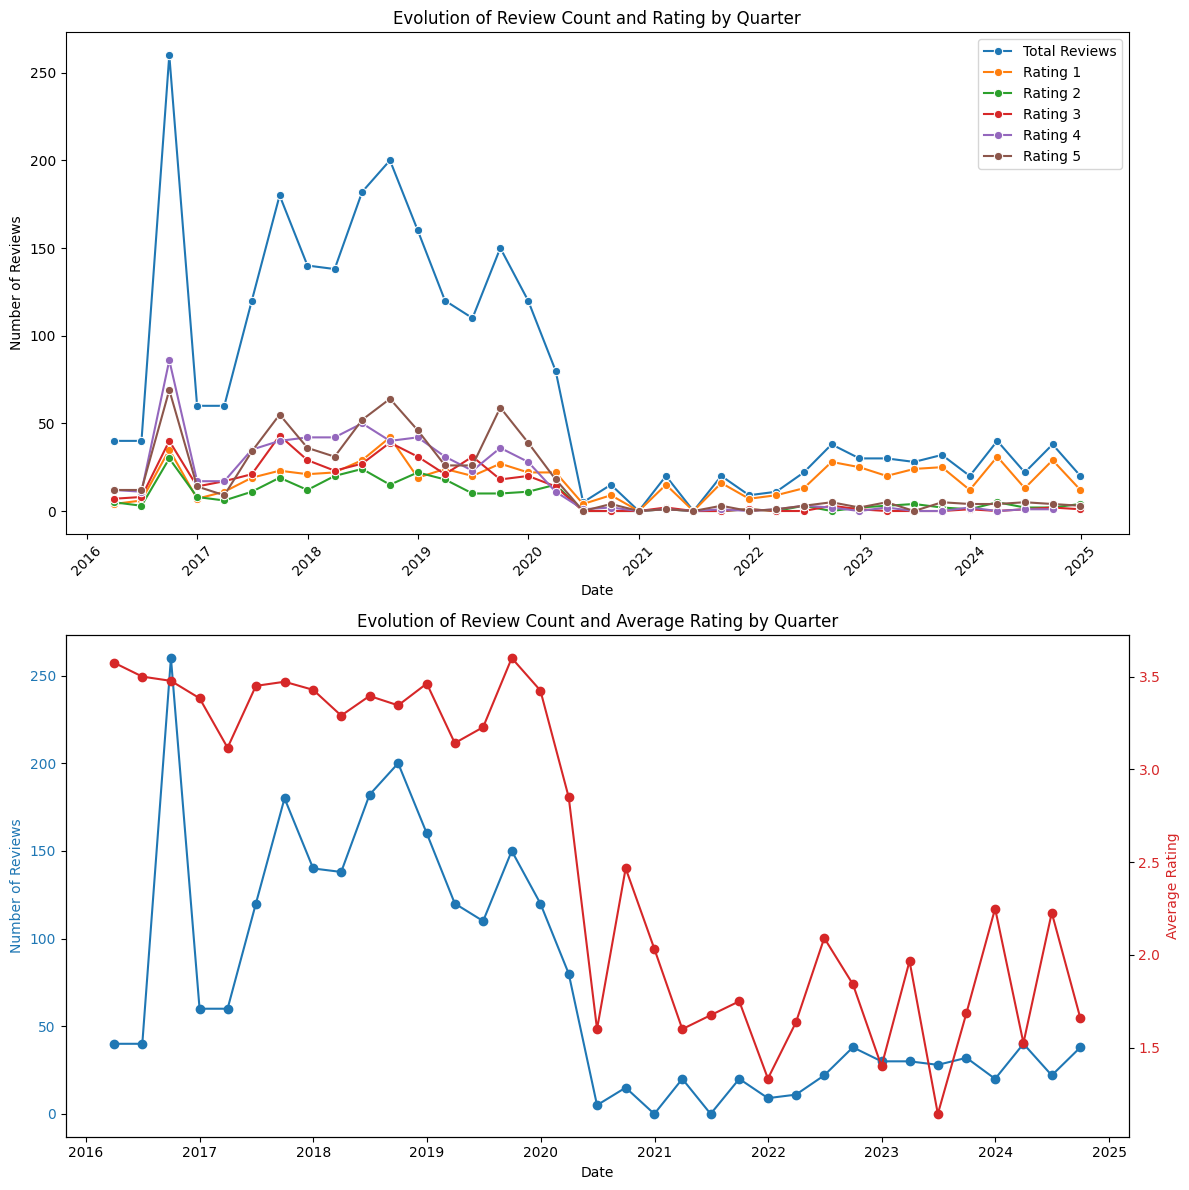

In [ ]:
overall = df_copy.set_index('publishedDate').resample('Q').size().reset_index(name='count')

monthly_counts = df_copy.set_index('publishedDate').resample('Q').size()
monthly_mean = df_copy.set_index('publishedDate').resample('Q')['rating'].mean()

date_range = pd.date_range(start=df_copy['publishedDate'].min(),
                           end=df_copy['publishedDate'].max(),
                           freq='Q')
monthly_counts = monthly_counts.reindex(date_range, fill_value=0)
monthly_mean = monthly_mean.reindex(date_range).interpolate()

merged = pd.DataFrame({
    'publishedDate': date_range,
    'count': monthly_counts.values,
    'rating': monthly_mean.values
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

sns.lineplot(data=overall, x='publishedDate', y='count', marker='o', label='Total Reviews', ax=ax1)
for rating in sorted(df['rating'].unique()):
    temp = df_copy[df_copy['rating'] == rating].set_index('publishedDate').resample('Q').size().reset_index(name='count')
    sns.lineplot(data=temp, x='publishedDate', y='count', marker='o', label=f'Rating {rating}', ax=ax1)

ax1.set_title("Evolution of Review Count and Rating by Quarter")
ax1.set_xlabel("Date")
ax1.set_ylabel("Number of Reviews")
ax1.tick_params(axis='x', rotation=45)
ax1.legend()

color1 = 'tab:blue'
ax2.set_xlabel('Date')
ax2.set_ylabel('Number of Reviews', color=color1)
ax2.plot(merged['publishedDate'], merged['count'], '-o', color=color1)
ax2.tick_params(axis='y', labelcolor=color1)

ax2b = ax2.twinx()
color2 = 'tab:red'
ax2b.set_ylabel('Average Rating', color=color2)
ax2b.plot(merged['publishedDate'], merged['rating'], '-o', color=color2)
ax2b.tick_params(axis='y', labelcolor=color2)

ax2.set_title("Evolution of Review Count and Average Rating by Quarter")

plt.tight_layout()
plt.show()

In [ ]:
avg_rating_year.T

,0,1,2,3,4,5,6,7,8
year,2016,2017,2018,2019,2020,2021,2022,2023,2024
rating,3.475,3.412,3.375,3.366,2.73,1.612245,1.742574,1.727273,1.758333


Observation:


*   Since the end of 2019 the rating of the reviews has dropped too much, reaching its lowest point in 2021, with most people giving them a 1 rating, going from an average rating in 2016 of about 3.5 to about 1.7 in 2024.
*   As their average rating dropped, so did the number of reviews given.



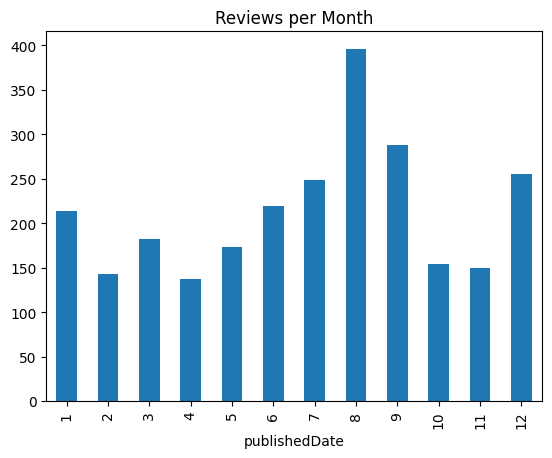

In [ ]:
monthly_counts = df_copy.groupby(df_copy['publishedDate'].dt.month).size()
monthly_counts.plot(kind='bar', title='Reviews per Month')
plt.show()


It seems that October is when there is a higher number of reviews.

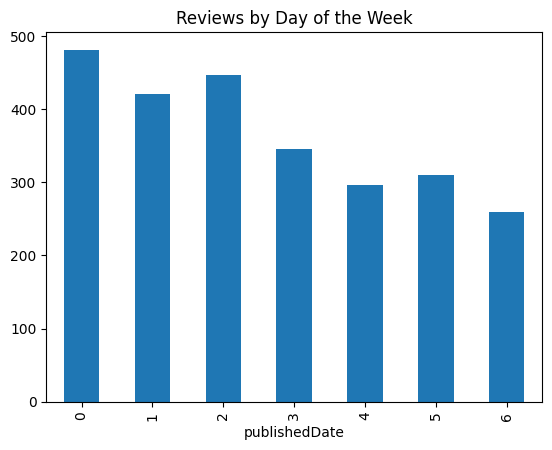

In [ ]:
day_of_week_counts = df_copy.groupby(df_copy['publishedDate'].dt.dayofweek).size()
day_of_week_counts.plot(kind='bar', title='Reviews by Day of the Week')
plt.show()


**Text data statistics**

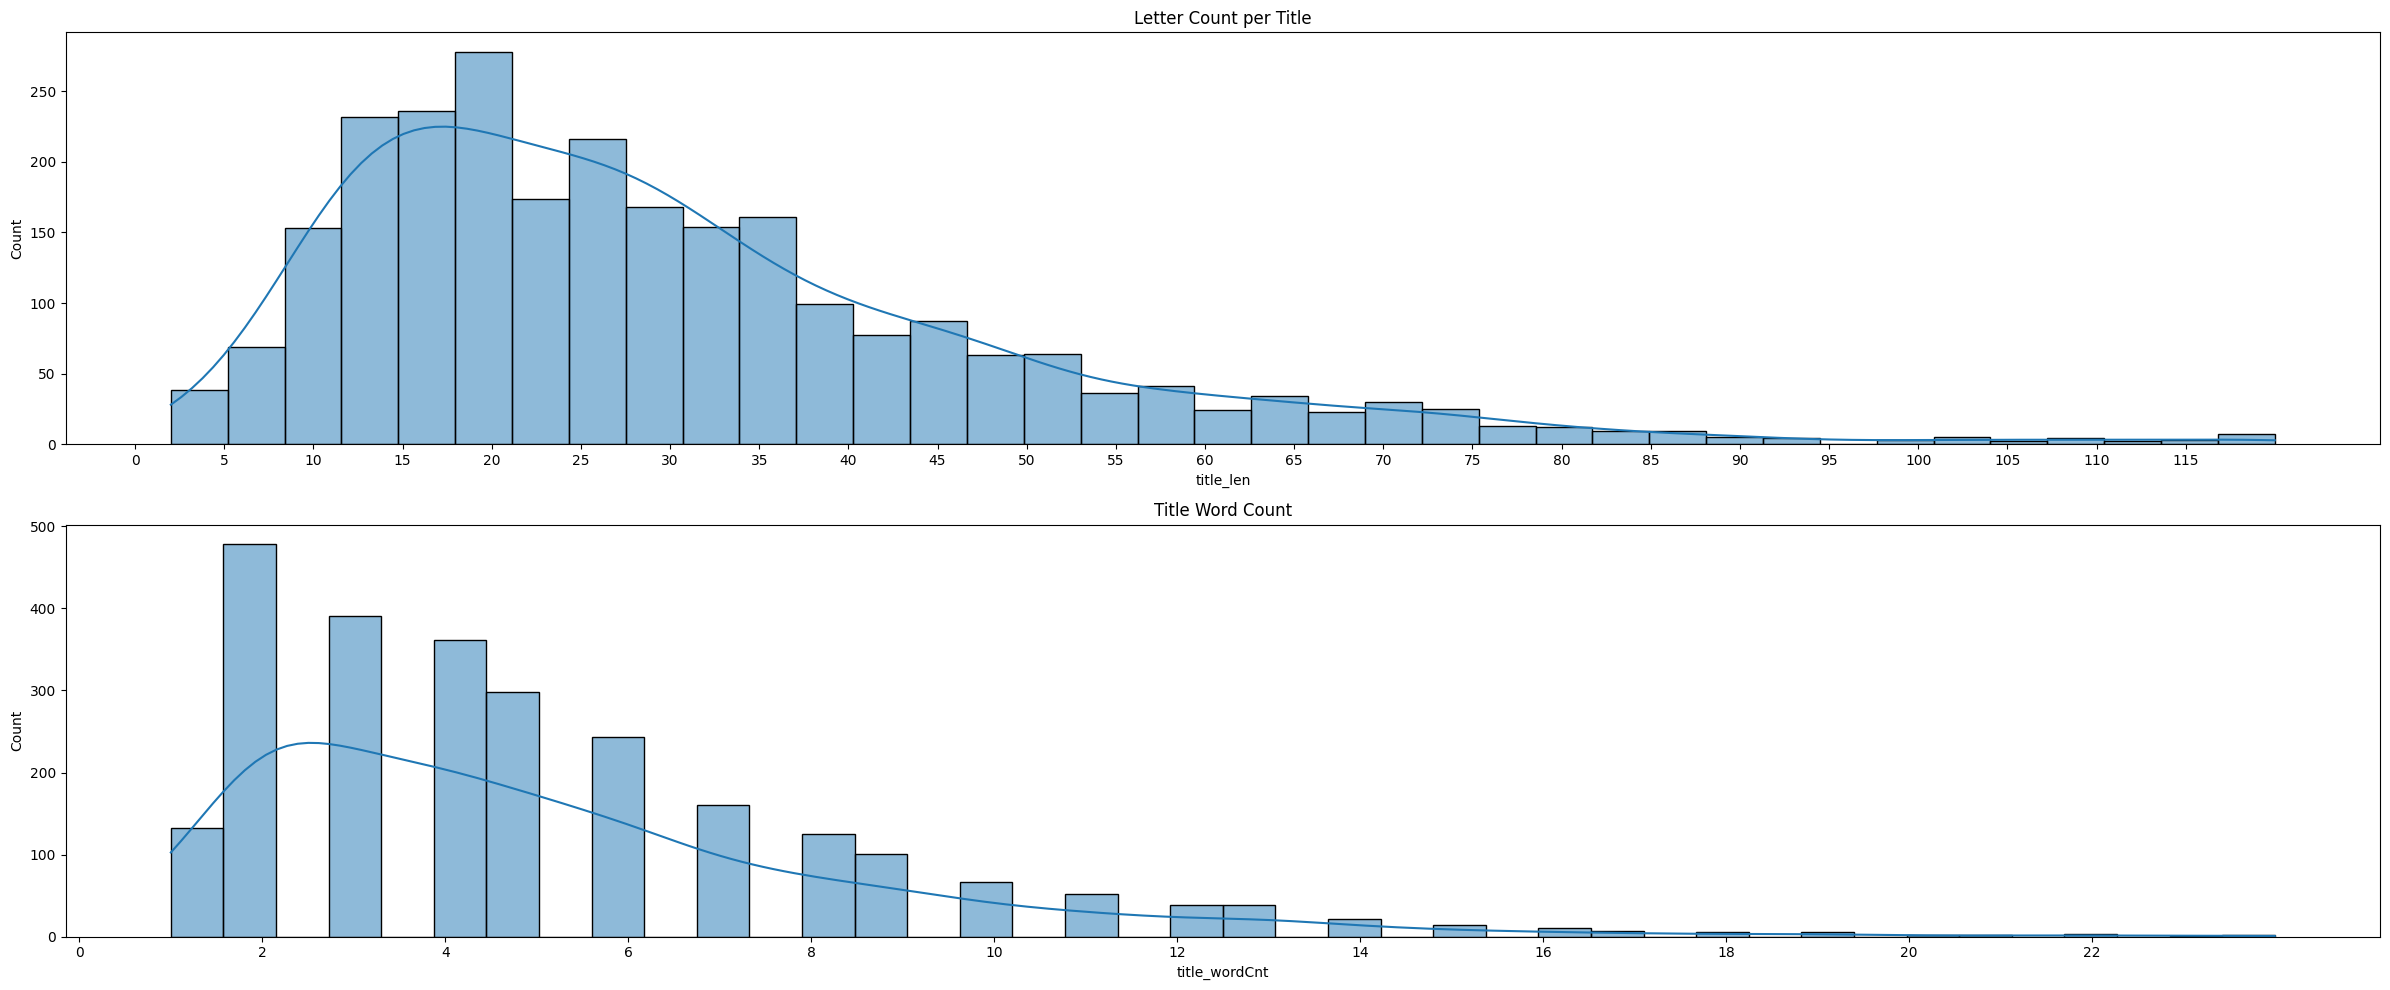

In [4]:
df['title_len'] = df['title'].apply(lambda x : len(x))
df['title_wordCnt'] = df['title'].apply(lambda x : len(x.split(' ')))

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 10))

sns.histplot(df['title_len'], ax=ax1, kde=True)
ax1.set_title("Letter Count per Title")
ax1.set_xticks(np.arange(0, df['title_len'].max(), step=5))

sns.histplot(df['title_wordCnt'], ax=ax2, kde=True)
ax2.set_title("Title Word Count")
ax2.set_xticks(np.arange(0, df['title_wordCnt'].max(), step=2))

plt.tight_layout()
plt.show()

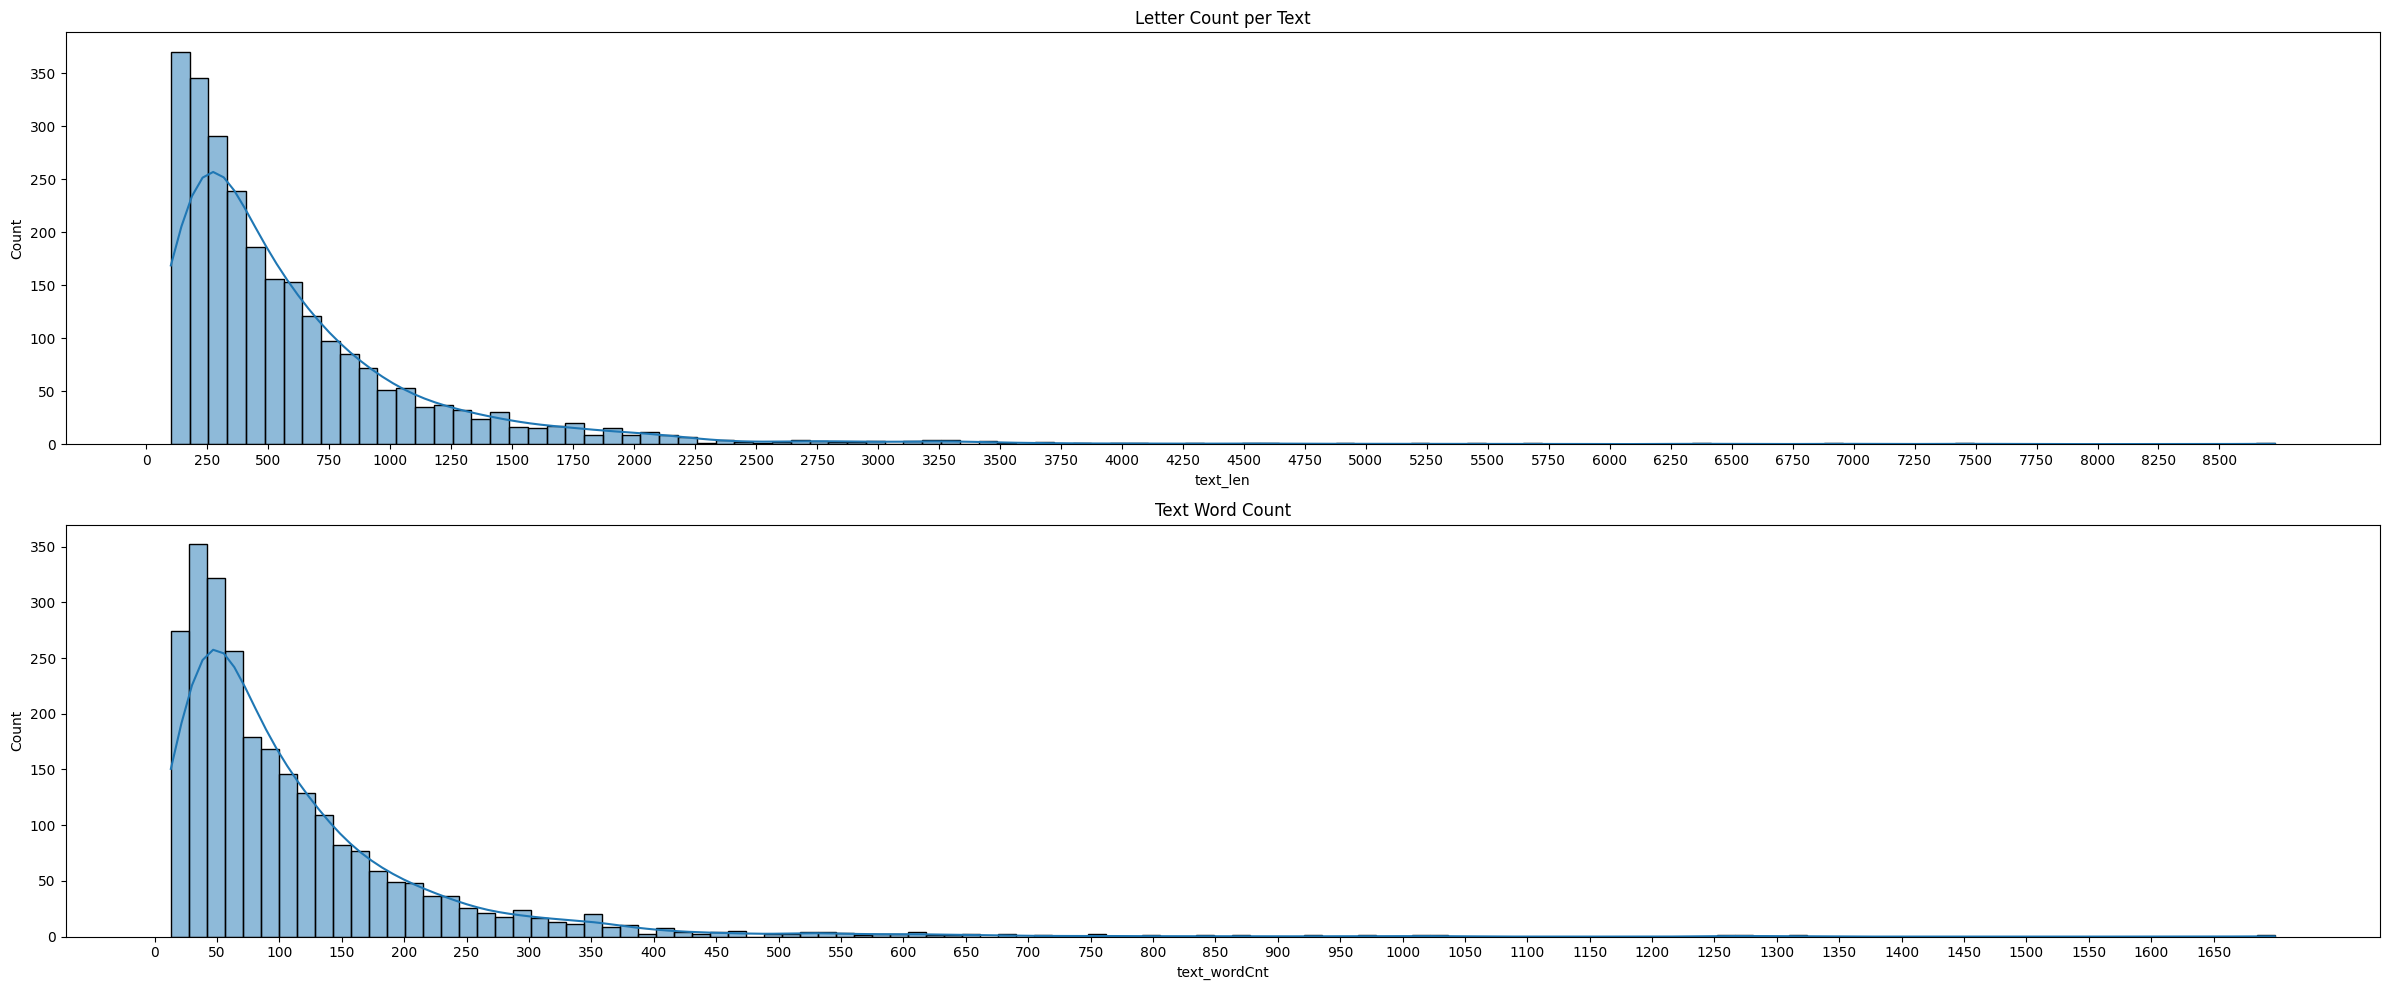

In [5]:
df['text_len'] = df['text'].apply(lambda x : len(x))
df['text_wordCnt'] = df['text'].apply(lambda x : len(x.split(' ')))

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24, 10))

sns.histplot(df['text_len'], ax=ax1, kde=True)
ax1.set_title("Letter Count per Text")
ax1.set_xticks(np.arange(0, df['text_len'].max(), step=250))

sns.histplot(df['text_wordCnt'], ax=ax2, kde=True)
ax2.set_title("Text Word Count")
ax2.set_xticks(np.arange(0, df['text_wordCnt'].max(), step=50))

plt.tight_layout()
plt.show()

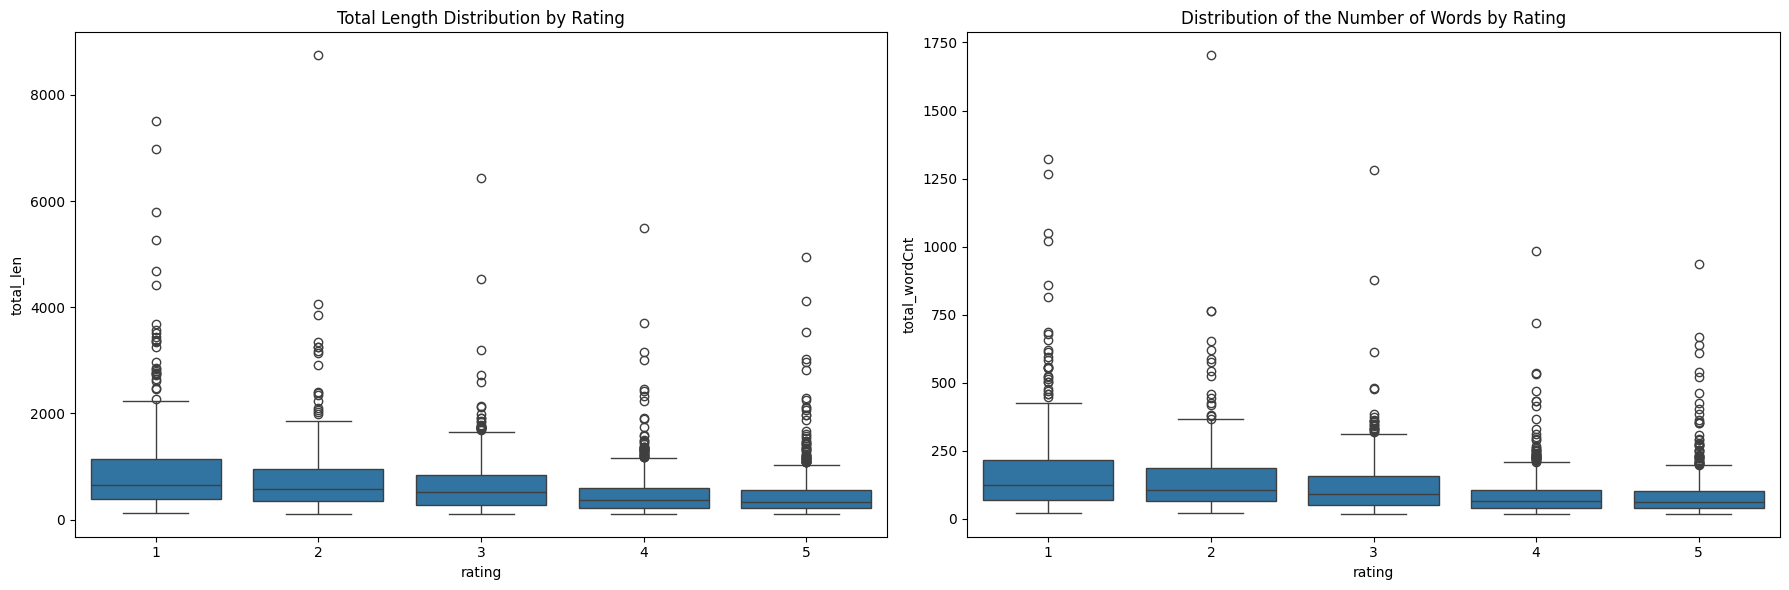

In [7]:
df['total_len'] = df['title_len'] + df['text_len']
df['total_wordCnt'] = df['title_wordCnt'] + df['text_wordCnt']

f, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(x=df['rating'], y=df['total_len'], ax=axes[0])
axes[0].set_title("Total Length Distribution by Rating")

sns.boxplot(x=df['rating'], y=df['total_wordCnt'], ax=axes[1])
axes[1].set_title("Distribution of the Number of Words by Rating")

plt.tight_layout()
plt.show()

We can clearly see that the lower the rating, the higher the number of words

## **Preprocessing**

In [ ]:
df.head()

,rating,title,text,publishedDate,title_len,title_wordCnt,text_len,text_wordCnt,total_len,total_wordCnt
0,1,WORST AIRLINE,I travel a lot - and I travel often. Last week...,2024-11-13,13,2,2133,408,2146,410
1,1,Terrible experience with Airfrance,"This review is regarding flight AF185, we book...",2024-11-13,34,4,891,154,925,158
2,1,Extremely Disappointing Experience with Air Fr...,I recently flew with Air France on flight #185...,2024-11-12,78,11,1579,250,1657,261
3,1,Horrible,Wow!!! What a horrible experience!! I've alway...,2024-11-11,8,1,1479,270,1487,271
4,1,The Worst Flight Experience I’ve Ever Had,I spent a fantastic 10-day vacation in Hong Ko...,2024-11-11,41,7,1815,308,1856,315


In [8]:
df['publishedDate'] = pd.to_datetime(df['publishedDate'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   rating         2560 non-null   int64         
 1   title          2560 non-null   object        
 2   text           2560 non-null   object        
 3   publishedDate  2560 non-null   datetime64[ns]
 4   title_len      2560 non-null   int64         
 5   title_wordCnt  2560 non-null   int64         
 6   text_len       2560 non-null   int64         
 7   text_wordCnt   2560 non-null   int64         
 8   total_len      2560 non-null   int64         
 9   total_wordCnt  2560 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(2)
memory usage: 200.1+ KB


We will normalize the text to further explore the data and future models.

In [9]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

def normalize_text(text):
    if not text:
        return ""

    text = text.lower()

    text = re.sub(r'@\w+|https?://\S+', '', text)

    text = re.sub(r'<[^>]+>', '', text)

    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub(r'\d+', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    stop_words = set(stopwords.words('english'))
    negations = {"no", "not", "nor", "n't", "never"}
    custom_stop_words = stop_words - negations
    tokens = [token for token in tokens if token not in custom_stop_words]

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return tokens

df['full_text'] = df.apply(lambda row: row['title'] + row['text'], axis=1)
df['clean_title'] = df['title'].apply(normalize_text)
df['clean_text'] = df['text'].apply(normalize_text)
df['full_text_tokenize'] = df.apply(lambda row: row['clean_title'] + row['clean_text'], axis=1)
df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


,rating,title,text,publishedDate,title_len,title_wordCnt,text_len,text_wordCnt,total_len,total_wordCnt,full_text,clean_title,clean_text,full_text_tokenize
0,1,WORST AIRLINE,I travel a lot - and I travel often. Last week...,2024-11-13,13,2,2133,408,2146,410,WORST AIRLINEI travel a lot - and I travel oft...,"[worst, airline]","[travel, lot, travel, often, last, week, flew,...","[worst, airline, travel, lot, travel, often, l..."
1,1,Terrible experience with Airfrance,"This review is regarding flight AF185, we book...",2024-11-13,34,4,891,154,925,158,Terrible experience with AirfranceThis review ...,"[terrible, experience, airfrance]","[review, regarding, flight, af, booked, econom...","[terrible, experience, airfrance, review, rega..."
2,1,Extremely Disappointing Experience with Air Fr...,I recently flew with Air France on flight #185...,2024-11-12,78,11,1579,250,1657,261,Extremely Disappointing Experience with Air Fr...,"[extremely, disappointing, experience, air, fr...","[recently, flew, air, france, flight, hong, ko...","[extremely, disappointing, experience, air, fr..."
3,1,Horrible,Wow!!! What a horrible experience!! I've alway...,2024-11-11,8,1,1479,270,1487,271,HorribleWow!!! What a horrible experience!! I'...,[horrible],"[wow, horrible, experience, ive, always, flown...","[horrible, wow, horrible, experience, ive, alw..."
4,1,The Worst Flight Experience I’ve Ever Had,I spent a fantastic 10-day vacation in Hong Ko...,2024-11-11,41,7,1815,308,1856,315,The Worst Flight Experience I’ve Ever HadI spe...,"[worst, flight, experience, ’, ever]","[spent, fantastic, day, vacation, hong, kong, ...","[worst, flight, experience, ’, ever, spent, fa..."


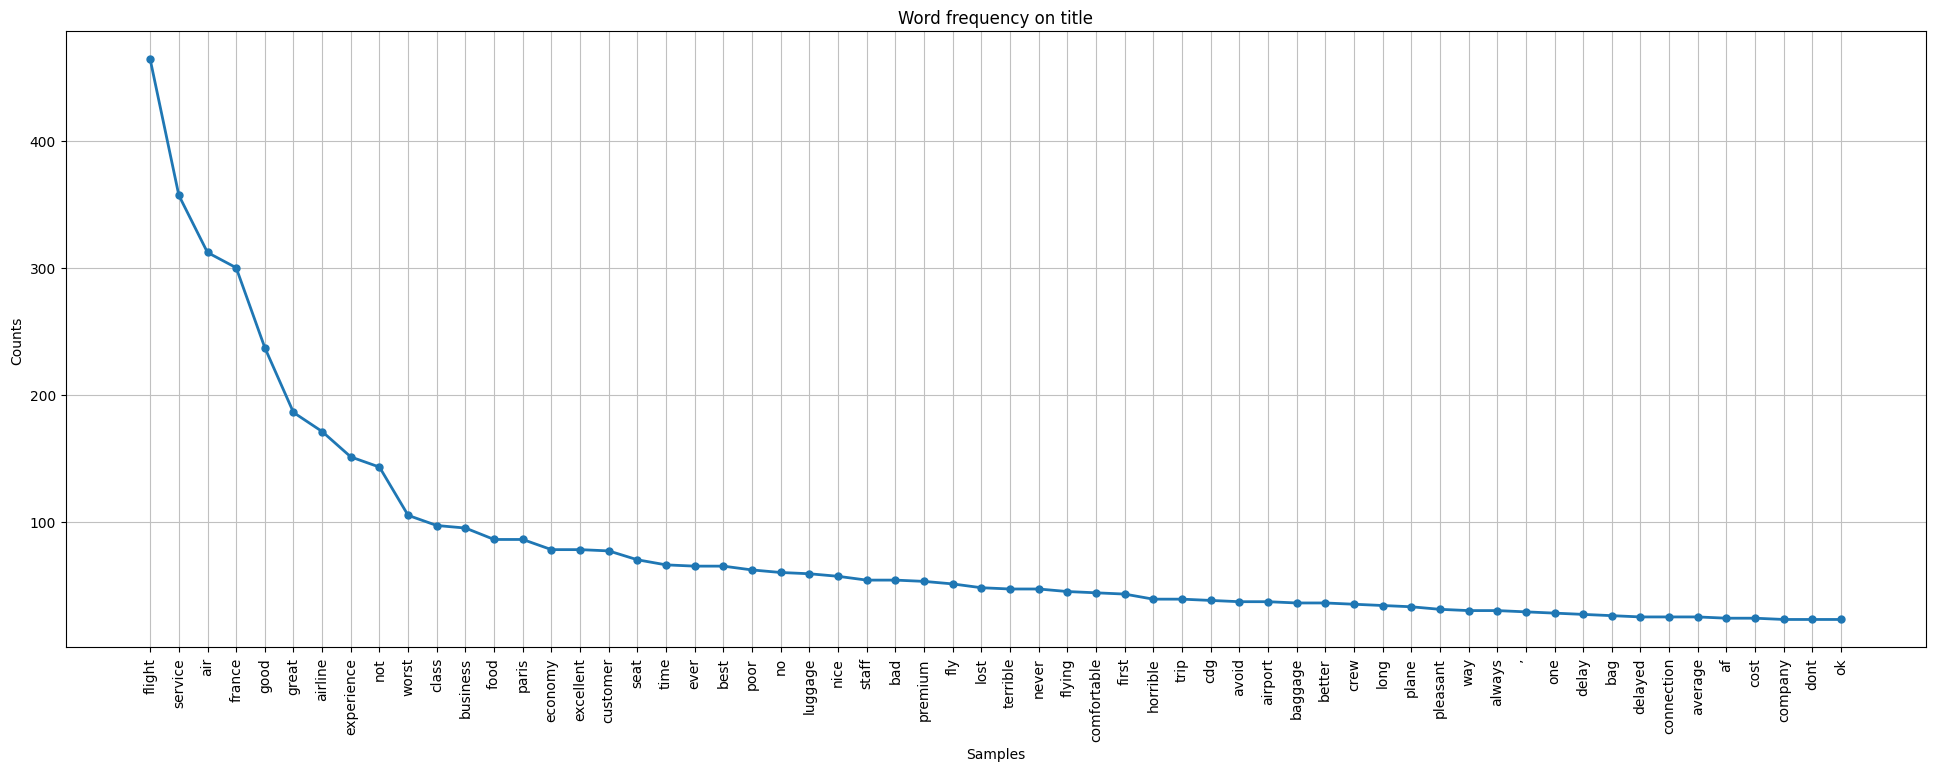

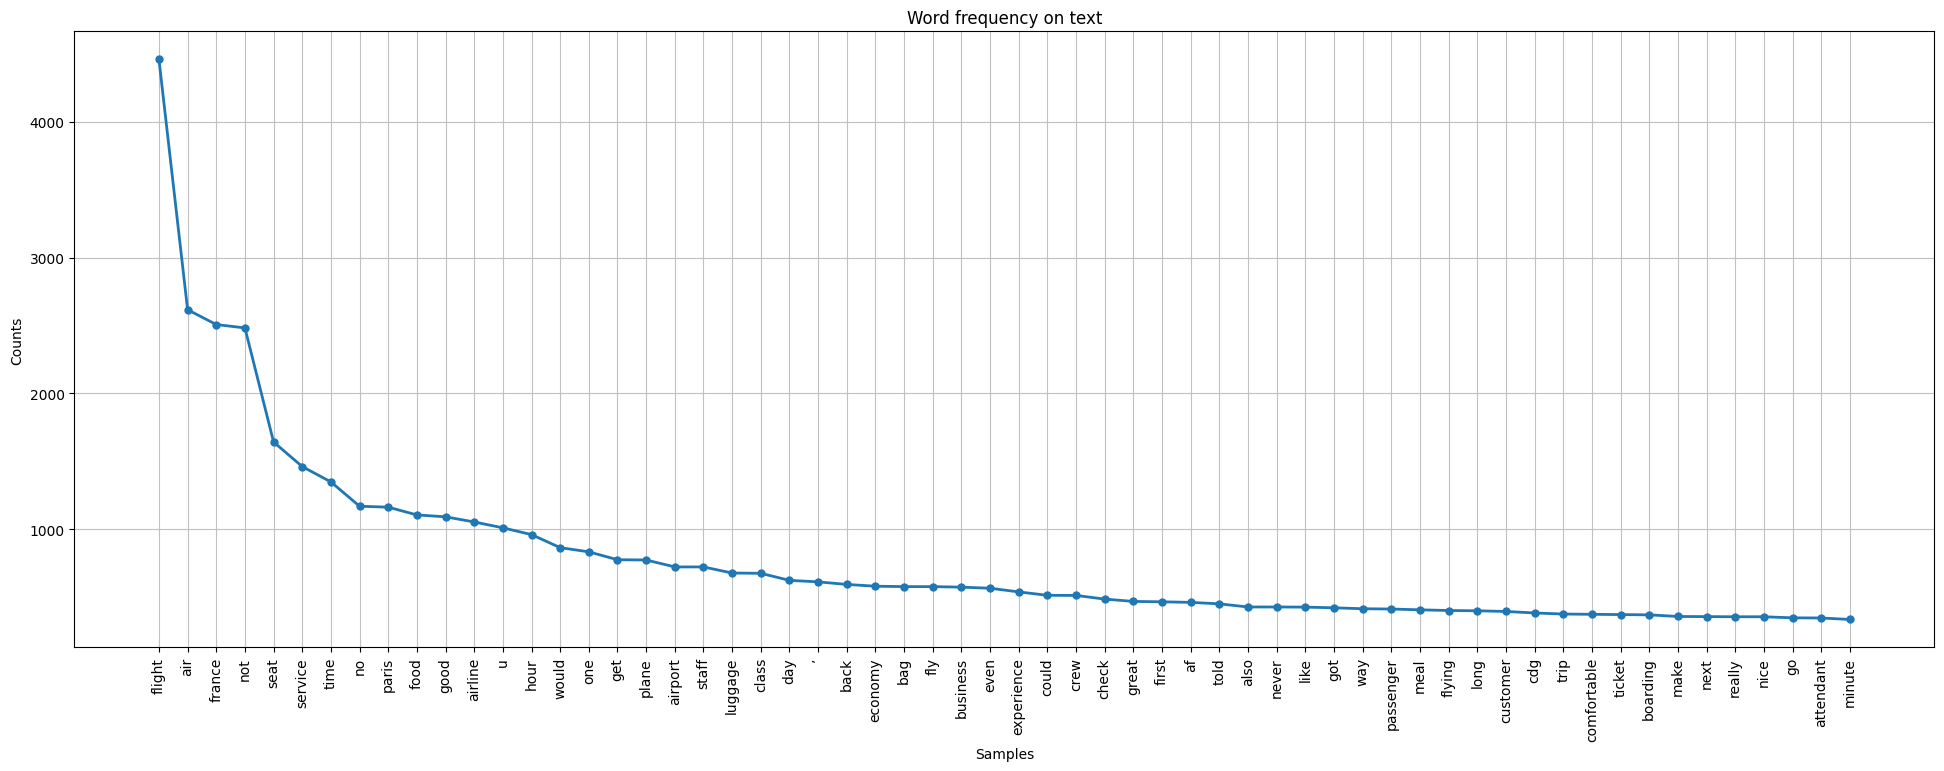

In [ ]:
freq_title = FreqDist([token for tokens in df['clean_title'] for token in tokens])
freq_text = FreqDist([token for tokens in df['clean_text'] for token in tokens])

plt.figure(figsize=(24,8))
plt.title('Word frequency on title')
freq_title.plot(60, marker='.', markersize=10)
plt.show()

plt.figure(figsize=(24,8))
plt.title('Word frequency on text')
freq_text.plot(60, marker='.', markersize=10)
plt.show()

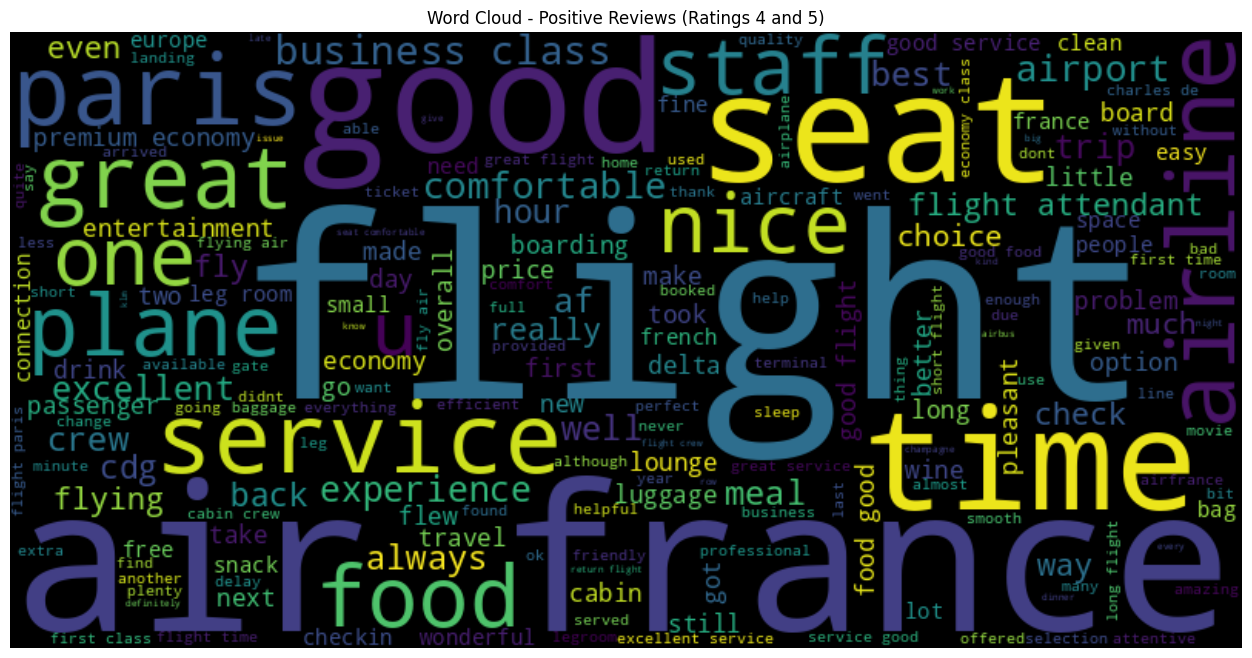

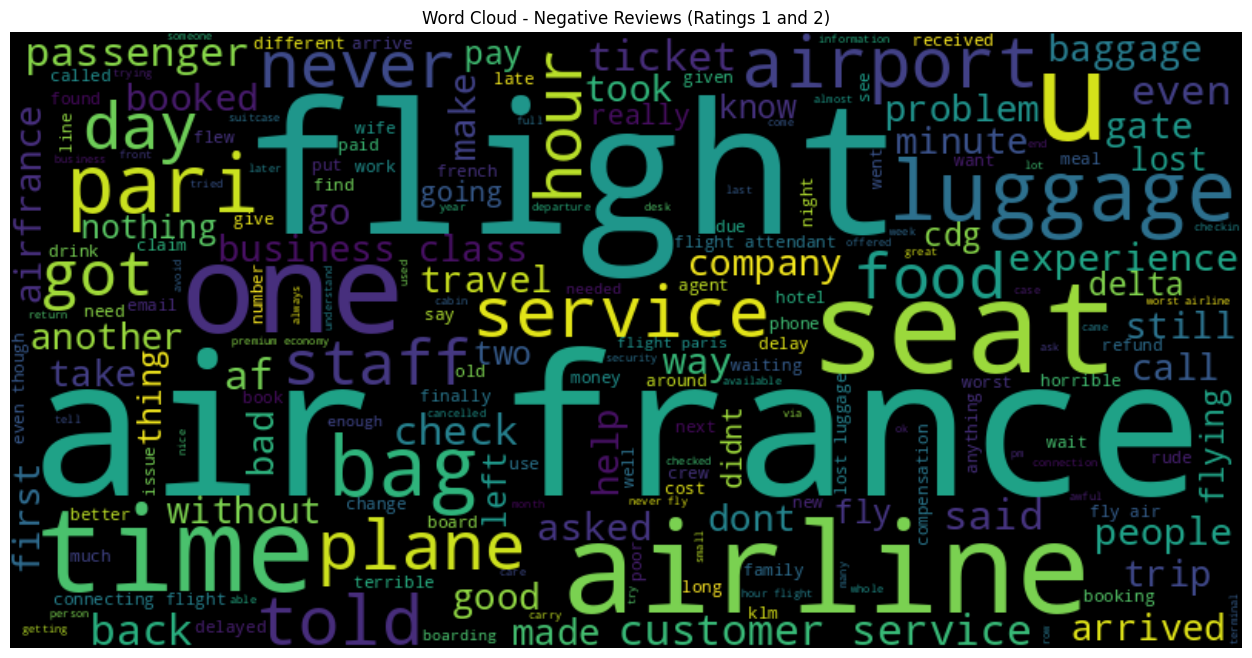

In [ ]:
all_positive_tokens = [token for tokens in df[df['rating'].isin([4, 5])]['full_text_tokenize'] for token in tokens]
all_negative_tokens = [token for tokens in df[df['rating'].isin([1, 2])]['full_text_tokenize'] for token in tokens]

wordcloud_positive = WordCloud(width=800, height=400).generate(' '.join(all_positive_tokens))
plt.figure(figsize=(20,8))
plt.title('Word Cloud - Positive Reviews (Ratings 4 and 5)')
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.show()

wordcloud_negative = WordCloud(width=800, height=400).generate(' '.join(all_negative_tokens))
plt.figure(figsize=(20,8))
plt.title('Word Cloud - Negative Reviews (Ratings 1 and 2)')
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.show()

## **Sentiment analysis**

Now let's look at what model we will use that best predicts sentiment, for this I plan to assign sentiment to comments based on their rating. 5 and 4 equals good, 3 equals neutral and 2 and 1 equals negative. While this is a way to classify the comments, there will be bias in this type of classification, because there are people who for example put 3 rating to their comment, but for them that rating is taken as negative and say many bad things in their comments.

For sentiment classification we will use NLTK's SentimentIntensityAnalyzer(), distilbert and roberta's transformer and I will also look for a machine learning model to see which one produces the best results and decide which one to use in the end.

In [10]:
def classify_sentiment(compound):
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

def assign_class(rating):
  if rating >= 4:
    return 'positive'
  elif rating == 3:
    return 'neutral'
  else:
    return 'negative'

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

df['text_sentiment_sia'] = df['full_text'].apply(lambda x: sia.polarity_scores(x)['compound'])

df['text_sentiment_sia'] = df['text_sentiment_sia'].apply(classify_sentiment)

df['rating_label'] = df['rating'].apply(assign_class)
df.isnull().sum()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


,0
rating,0
title,0
text,0
publishedDate,0
title_len,0
title_wordCnt,0
text_len,0
text_wordCnt,0
total_len,0
total_wordCnt,0


In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    revision="714eb0f"
)

df['transformer_sentiment_distilbert'] = df['full_text'].apply(lambda x: sentiment_pipeline(x, truncation=True)[0]['label'])

Device set to use cpu


In [ ]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment",
)

label_mapping = {
    "LABEL_0": "NEGATIVE",
    "LABEL_1": "NEUTRAL",
    "LABEL_2": "POSITIVE"
}

df['transformer_sentiment_roberta'] = df['full_text'].apply(
    lambda x: label_mapping[sentiment_pipeline(x, truncation=True, max_length=512)[0]['label']]
)

Device set to use cpu


As a metric I will use the f1_score macro to evaluate the performance of the models, the use of macro is to take into account that all classes are equally important, even if they are unbalanced.

In [ ]:
df['true_sentiment'] = df['rating'].apply(lambda x: 0 if x <= 2 else (2 if x >= 4 else 1))
label_mapping = {'NEGATIVE': 0, 'NEUTRAL': 1, 'POSITIVE': 2}
label_mapping2 = {'negative': 0, 'neutral': 1, 'positive': 2}

df['distilbert_result'] = df['transformer_sentiment_distilbert'].map(label_mapping)
df['roberta_result'] = df['transformer_sentiment_roberta'].map(label_mapping)
df['sia_result'] = df['text_sentiment_sia'].map(label_mapping2)

print("Evaluación SST-2:")
print(f1_score(df['true_sentiment'], df['distilbert_result'], average='macro'))

print("Evaluación RoBERTa:")
print(f1_score(df['true_sentiment'], df['roberta_result'], average='macro'))

print("Evaluación sia:")
print(f1_score(df['true_sentiment'], df['sia_result'],average='macro'))

print("Matriz de Confusión SST-2:")
print(confusion_matrix(df['true_sentiment'], df['distilbert_result']))

print("Matriz de Confusión RoBERTa:")
print(confusion_matrix(df['true_sentiment'], df['roberta_result']))

print("Matriz de Confusión sia:")
print(confusion_matrix(df['true_sentiment'], df['sia_result']))

Evaluación SST-2:
0.5447539246379409
Evaluación RoBERTa:
0.6683414691557114
Evaluación sia:
0.5450250407361718
Matriz de Confusión SST-2:
[[ 899    0   15]
 [ 337    0   78]
 [ 208    0 1023]]
Matriz de Confusión RoBERTa:
[[ 878   24   12]
 [ 246   74   95]
 [  55   62 1114]]
Matriz de Confusión sia:
[[ 722   10  182]
 [ 183    9  223]
 [  65   10 1156]]


For ML models we are going to try different types of models. We will use Word2Vec to vectorize the text and look for the best hyperparameters of the models to see which one performs better.

In [ ]:
def text_to_vector(tokens, model):
    word_vectors = [model[word] for word in tokens if word in model]
    if not word_vectors:
        return np.zeros(model.vector_size)
    return np.mean(word_vectors, axis=0)

def get_models():
    models, names = list(), list()
    models.append(LogisticRegression())
    names.append('LR')
    models.append(XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False, random_state=42))
    names.append('XGB')
    models.append(KNeighborsClassifier())
    names.append('KNC')
    models.append(RandomForestClassifier(random_state=42))
    names.append('RFC')
    return models, names

def evaluate_model(X, y, model):
    scores = cross_val_score(model, X, y, scoring='f1_macro', cv=5, n_jobs=-1)
    return scores

df_ml = df[['total_len', 'full_text_tokenize', 'true_sentiment', 'roberta_result']]
model_path = "/content/drive/MyDrive/GoogleNews-vectors-negative300.bin"
google_model = KeyedVectors.load_word2vec_format(model_path, binary=True)

text_vectors = np.array([text_to_vector(tokens, google_model) for tokens in df['full_text_tokenize']])

scaler = StandardScaler()
total_len_scaled = scaler.fit_transform(df_ml[['total_len']])
encoder = OneHotEncoder(sparse_output=False)
roberta_encoded = encoder.fit_transform(df_ml['roberta_result'].values.reshape(-1, 1))

X = np.hstack((text_vectors, total_len_scaled, roberta_encoded))

y = df['true_sentiment']

models, names = get_models()
results = list()

for i in range(len(models)):
  scores = evaluate_model(X, y, models[i])
  results.append(scores)
  print('>%s %.3f (%.3f)' % (names[i], abs(np.mean(scores)), np.std(scores)))

>LR 0.683 (0.012)
>XGB 0.703 (0.016)
>KNC 0.681 (0.012)
>RFC 0.640 (0.010)


In [ ]:
def tune_model_random(model, param_dist, X, y, n_iter=50):
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        scoring='f1_macro',
        cv=5,
        n_jobs=-1,
        n_iter=n_iter,
        random_state=42
    )
    random_search.fit(X, y)
    print(f"Best parameters for {model} are {random_search.best_params_} and its best F1 is {random_search.best_score_:.2f}")
    return random_search.best_estimator_

param_grid_lr = [
    {
        'penalty': ['l1'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['liblinear']
    },
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'sag', 'saga']
    }
]

param_grid_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.001, 0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.5, 0.7, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0, 1, 10]
}

param_grid_knc = {
    'n_neighbors': list(range(1, 31)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

param_grid_rfc = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
    'max_features': ['auto', 'sqrt', 'log2']
}


In [ ]:
best_lr_random = tune_model_random(LogisticRegression(), param_grid_lr, X, y)

Best parameters for LogisticRegression() are {'solver': 'sag', 'penalty': 'l2', 'C': 10} and its best F1 is 0.72


In [ ]:
best_rfc_random = tune_model_random(RandomForestClassifier(), param_grid_rfc, X, y)

Best parameters for RandomForestClassifier() are {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False} and its best F1 is 0.65


In [ ]:
best_knc_random = tune_model_random(KNeighborsClassifier(), param_grid_knc, X, y)

Best parameters for KNeighborsClassifier() are {'weights': 'distance', 'p': 1, 'n_neighbors': 9, 'algorithm': 'auto'} and its best F1 is 0.69


In [ ]:
best_xgb_random = tune_model_random(XGBClassifier(objective='multi:softmax', num_class=3, eval_metric='mlogloss', use_label_encoder=False), param_grid_xgb, X, y)

Best parameters for XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=3, num_parallel_tree=None, ...) are {'subsample': 0.7, 'reg_lambda': 0, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.5} and its best F1 is 0.71


**Conclusion:**

We can see that the transformer with the highest score is the roberta transformer with a 0.66 score on f1_socre, while the ML model with the highest score was the logistic regression model with a 0.72 score on f1_socre.

After thinking about it for a while, I decided that I will use roberta's transformer because of the bias in the data that surely affected her result and because transformers usually make better predictions than conventional machine learning models since they understand the context better.

## **Topic Modeling**

In [13]:
import logging
from gensim.corpora import Dictionary
from gensim.models.ldaseqmodel import LdaSeqModel

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

df['year'] = df['publishedDate'].dt.year

docs_by_year = df.groupby('year')['full_text_tokenize'].apply(list)
years = sorted(docs_by_year.index)
time_slices = [len(docs_by_year[year]) for year in years]

print("Years:", years)
print("Number of documents per slice:", time_slices)

documents = [doc for docs in docs_by_year for doc in docs]
dictionary = Dictionary(documents)

dictionary.filter_extremes(no_below=5, no_above=0.5)

corpus = []
for year in years:
    for doc in docs_by_year[year]:
        corpus.append(dictionary.doc2bow(doc))

num_topics = 5

ldaseq = LdaSeqModel(corpus=corpus,
                     time_slice=time_slices,
                     id2word=dictionary,
                     num_topics=num_topics,
                     passes=10)


Years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
Number of documents per slice: [400, 500, 680, 500, 100, 49, 101, 110, 120]

=== Evolución del Tema #0 ===


TypeError: LdaSeqModel.print_topic_times() got an unexpected keyword argument 'word_count'

In [14]:
for topic in range(num_topics):
    print(f"\n=== Evolución del Tema #{topic} ===")
    topic_times = ldaseq.print_topic_times(topic)
    for t, topic_rep in enumerate(topic_times):
        print(f"Slice temporal {t+1} ({years[t]}): {topic_rep}")


=== Evolución del Tema #0 ===
Slice temporal 1 (2016): [('day', 0.015223511392131702), ('luggage', 0.014167662855324822), ('paris', 0.012496863187198814), ('no', 0.011684418600732853), ('service', 0.010326324494359536), ('would', 0.010307367907849767), ('u', 0.010186367778227323), ('hour', 0.009791038685726035), ('time', 0.009220908263819244), ('airline', 0.0089285741689195), ('customer', 0.008651868792566953), ('airport', 0.00763199887163272), ('lost', 0.007510142700973039), ('told', 0.006963835757668959), ('get', 0.006956022671670985), ('bag', 0.006656401858841257), ('ticket', 0.005962466587916618), ('baggage', 0.005645364244691597), ('could', 0.005425379282026757), ('one', 0.005328311015623251)]
Slice temporal 2 (2017): [('day', 0.015761478392368026), ('luggage', 0.014063857847467564), ('paris', 0.012265064580426628), ('no', 0.01180694219182575), ('service', 0.010434778200428738), ('would', 0.01006298750231225), ('u', 0.0100118854386654), ('hour', 0.009815506795119), ('airline', 0.

In [18]:
import numpy as np
import pandas as pd
import plotly.express as px

all_topic_distributions = [ldaseq.doc_topics(i) for i in range(len(corpus))]

mean_topic_props = []
start_idx = 0
for slice_len in time_slices:
    end_idx = start_idx + slice_len
    slice_gamma = all_topic_distributions[start_idx:end_idx]
    mean_gamma = np.mean(slice_gamma, axis=0)
    mean_topic_props.append(mean_gamma)
    start_idx = end_idx

df_topics = pd.DataFrame(mean_topic_props, columns=[f"Topic {i}" for i in range(num_topics)])
df_topics["Year"] = years
df_topics = df_topics[["Year"] + [f"Topic {i}" for i in range(num_topics)]]

fig = px.line(df_topics,
              x='Year',
              y=[f"Topic {i}" for i in range(num_topics)],
              markers=True,
              title="Evolución de temas a lo largo del tiempo",
              labels={"value": "Proporción media", "variable": "Tema"})
fig.show()


In [19]:
for topic_id in range(num_topics):
    print(f"\n=== Evolución del Tema #{topic_id} ===")
    for t, year in enumerate(years):
        topic_terms = ldaseq.print_topic(topic=topic_id, time=t, top_terms=10)
        print(f"Año {year}: {topic_terms}")



=== Evolución del Tema #0 ===
Año 2016: [('day', 0.015223511392131702), ('luggage', 0.014167662855324822), ('paris', 0.012496863187198814), ('no', 0.011684418600732853), ('service', 0.010326324494359536), ('would', 0.010307367907849767), ('u', 0.010186367778227323), ('hour', 0.009791038685726035), ('time', 0.009220908263819244), ('airline', 0.0089285741689195)]
Año 2017: [('day', 0.015761478392368026), ('luggage', 0.014063857847467564), ('paris', 0.012265064580426628), ('no', 0.01180694219182575), ('service', 0.010434778200428738), ('would', 0.01006298750231225), ('u', 0.0100118854386654), ('hour', 0.009815506795119), ('airline', 0.0090697160969877), ('time', 0.00904806371461544)]
Año 2018: [('day', 0.016638868551929236), ('luggage', 0.014117384583684335), ('no', 0.012462709940759212), ('paris', 0.012021844441021272), ('service', 0.010656770827164985), ('hour', 0.010033449151049397), ('would', 0.009820126420458325), ('u', 0.00967412573020795), ('time', 0.009184152127230914), ('airline